In [ ]:
import pandas as pd
import numpy as np


In [ ]:
# Load your merged CSV
file_path = "/content/drive/MyDrive/GEE_Forest_TimeSeries/TamilNadu_Forest_TimeSeries_Master.csv"
df = pd.read_csv(file_path)

print(df.head())
print(df.columns)


             system:index       BSI  Forest       NBR      NDMI      NDVI  \
0  000000000000000062b6_0 -0.182323       1  0.517426  0.212965  0.767369   
1  000000000000000062b6_0 -0.100985       1  0.319837  0.141631  0.449275   
2  000000000000000062b6_0 -0.082196       1  0.313648  0.118453  0.444329   
3  000000000000000062b6_0 -0.086801       1  0.309993  0.124865  0.452542   
4  000000000000000062b7_0 -0.197501       1  0.536848  0.232422  0.766912   

   year                                               .geo  longitude  \
0  2021  {"geodesic":false,"type":"Point","coordinates"...  77.144172   
1  2022  {"geodesic":false,"type":"Point","coordinates"...  77.144172   
2  2023  {"geodesic":false,"type":"Point","coordinates"...  77.144172   
3  2024  {"geodesic":false,"type":"Point","coordinates"...  77.144172   
4  2021  {"geodesic":false,"type":"Point","coordinates"...  77.145071   

   latitude  
0  8.994382  
1  8.994382  
2  8.994382  
3  8.994382  
4  8.994382  
Index(['system

In [ ]:
features = ['NDVI', 'NDMI', 'NBR', 'BSI']
df = df[['latitude', 'longitude', 'year'] + features]

df = df.dropna()


In [ ]:
df = df.sort_values(by=['latitude', 'longitude', 'year'])


In [ ]:
sequence_length = 4  # 2021–2024
X = []
locations = []

for (lat, lon), group in df.groupby(['latitude', 'longitude']):
    if len(group) == sequence_length:
        X.append(group[features].values)
        locations.append([lat, lon])

X = np.array(X)
locations = np.array(locations)

print("LSTM input shape:", X.shape)


LSTM input shape: (30000, 4, 4)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_reshaped = X.reshape(-1, X.shape[-1])
X_scaled = scaler.fit_transform(X_reshaped)
X = X_scaled.reshape(X.shape)

print("Normalized input shape:", X.shape)


Normalized input shape: (30000, 4, 4)


In [ ]:
# NDVI and BSI changes across time
ndvi_change = X[:, 0, 0] - X[:, -1, 0]   # first year - last year
bsi_change  = X[:, -1, 3] - X[:, 0, 3]   # last year - first year


In [ ]:
y = ((ndvi_change > 0.25) | (bsi_change > 0.20)).astype(int)

print("Label distribution:")
print("No deforestation:", (y == 0).sum())
print("Deforestation:", (y == 1).sum())


Label distribution:
No deforestation: 23627
Deforestation: 6373


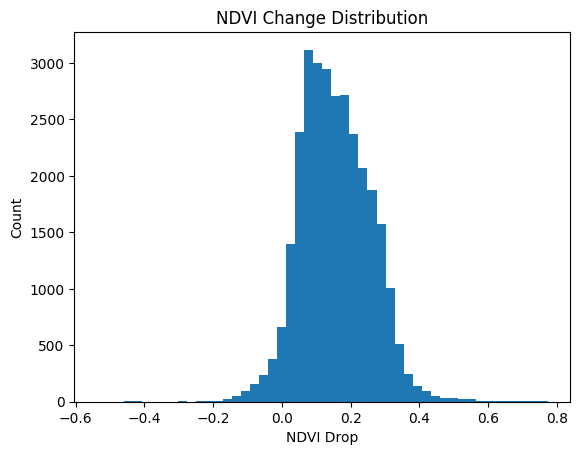

In [ ]:
import matplotlib.pyplot as plt

plt.hist(ndvi_change, bins=50)
plt.title("NDVI Change Distribution")
plt.xlabel("NDVI Drop")
plt.ylabel("Count")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (24000, 4, 4)
Test shape: (6000, 4, 4)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [ ]:
model = Sequential()

model.add(LSTM(
    64,
    input_shape=(X.shape[1], X.shape[2]),
    return_sequences=False
))

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Binary output


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=128,
    verbose=1
)


Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7677 - loss: 0.5324 - val_accuracy: 0.8320 - val_loss: 0.3616
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8541 - loss: 0.3253 - val_accuracy: 0.9138 - val_loss: 0.2043
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9128 - loss: 0.2093 - val_accuracy: 0.9405 - val_loss: 0.1565
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9265 - loss: 0.1770 - val_accuracy: 0.9443 - val_loss: 0.1375
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9353 - loss: 0.1546 - val_accuracy: 0.9497 - val_loss: 0.1305
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9388 - loss: 0.1517 - val_accuracy: 0.9505 - val_loss: 0.1225
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9412 - loss: 0.1421 - val_accuracy: 0.9390 - val_loss: 0.1393
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9389 - loss: 0.1471 - val_accuracy

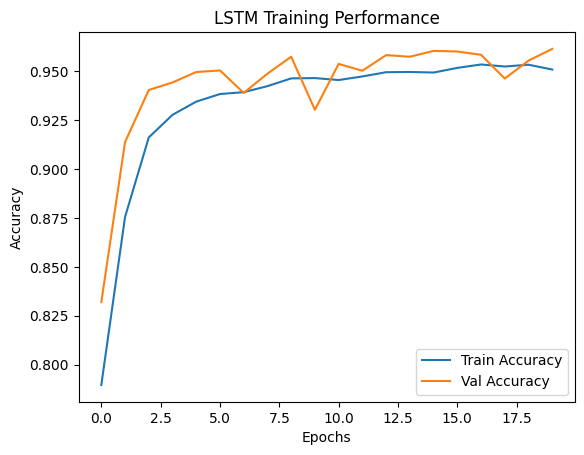

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('LSTM Training Performance')
plt.show()


In [ ]:
# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int)


188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


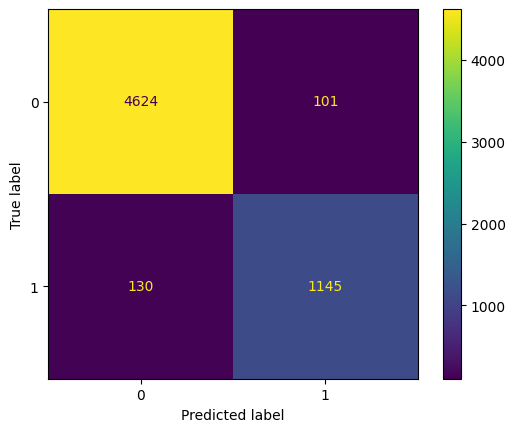

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      4725
           1       0.92      0.90      0.91      1275

    accuracy                           0.96      6000
   macro avg       0.95      0.94      0.94      6000
weighted avg       0.96      0.96      0.96      6000



In [ ]:
print("Locations shape:", locations.shape)
print("Predictions shape:", y_pred.shape)


Locations shape: (30000, 2)
Predictions shape: (6000, 1)


In [ ]:
import pandas as pd

# Check shapes (for confirmation)
print("Locations:", locations.shape)
print("Predictions:", y_pred.shape)

# Match sizes safely
n = y_pred.shape[0]   # 6000

results_df = pd.DataFrame({
    'latitude': locations[:n, 0],
    'longitude': locations[:n, 1],
    'deforestation': y_pred.flatten()
})

print(results_df.head())

# Save output
results_df.to_csv('Deforestation_Predictions.csv', index=False)
print("Saved: Deforestation_Predictions.csv")


Locations: (30000, 2)
Predictions: (6000, 1)
   latitude  longitude  deforestation
0  8.994382  77.144172              0
1  8.994382  77.145071              0
2  8.995280  77.144172              0
3  8.995280  77.145071              1
4  8.996178  77.145071              0
Saved: Deforestation_Predictions.csv


In [ ]:
!pwd


/content


In [ ]:
import pandas as pd

# Make sure lengths match
n = y_pred.shape[0]  # number of predictions

results_df = pd.DataFrame({
    'latitude': locations[:n, 0],
    'longitude': locations[:n, 1],
    'deforestation': y_pred.flatten()
})

print(results_df.head())

# Save permanently to Google Drive
from google.colab import drive
drive.mount('/content/drive')

results_df.to_csv('/content/drive/MyDrive/Deforestation_Predictions.csv', index=False)
print("Saved to Google Drive: Deforestation_Predictions.csv")


   latitude  longitude  deforestation
0  8.994382  77.144172              0
1  8.994382  77.145071              0
2  8.995280  77.144172              0
3  8.995280  77.145071              1
4  8.996178  77.145071              0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive: Deforestation_Predictions.csv
